In [98]:
import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split, cross_val_score
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
from sklearn.preprocessing import PowerTransformer, QuantileTransformer
import warnings

warnings.filterwarnings('ignore')

# 加载数据
df = pd.read_csv('./digit-recognizer/train.csv')
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

# 数据预处理：使用更好的变换方法
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')
X_transformed = pt.fit_transform(X / 255.0)

# 划分数据
X_train, X_test, y_train, y_test = train_test_split(
    X_transformed, y, test_size=0.2, random_state=42, stratify=y
)

# 定义超参数搜索空间
search_spaces = {
    'var_smoothing': Real(1e-11, 1e-2, prior='log-uniform'),
}

# 使用贝叶斯优化搜索最佳参数
opt = BayesSearchCV(
    GaussianNB(),
    search_spaces,
    n_iter=100,  # 增加迭代次数
    cv=5,  # 5折交叉验证
    n_jobs=8,  # 使用8个核心并行
    verbose=1
)

print("开始贝叶斯超参数优化...")
opt.fit(X_train, y_train)

print(f"最佳参数: {opt.best_params_}")
print(f"最佳交叉验证分数: {opt.best_score_:.4f}")

# 最终评估
best_model = opt.best_estimator_
final_accuracy = best_model.score(X_test, y_test)
print(f"测试集准确率: {final_accuracy:.4f}")

开始贝叶斯超参数优化...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, 

改进版手写数字识别 - 贝叶斯分类器
数据加载完成!
样本数量: 42000
特征维度: 784
类别分布: {np.int64(0): np.int64(4132), np.int64(1): np.int64(4684), np.int64(2): np.int64(4177), np.int64(3): np.int64(4351), np.int64(4): np.int64(4072), np.int64(5): np.int64(3795), np.int64(6): np.int64(4137), np.int64(7): np.int64(4401), np.int64(8): np.int64(4063), np.int64(9): np.int64(4188)}
方差特征选择: 784 -> 545 个特征
PCA降维: 545 -> 100 个特征
PCA保留方差比例: 0.9156
数据划分完成:
- 训练集: (33600, 100)
- 测试集: (8400, 100)

创建集成贝叶斯模型...
模型训练完成! 耗时: 1.42秒

模型评估结果:
训练集准确率: 0.8727
测试集准确率: 0.8715
错误分类数: 1079/8400

详细分类报告:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       827
           1       0.98      0.94      0.96       937
           2       0.77      0.87      0.81       835
           3       0.85      0.83      0.84       870
           4       0.88      0.84      0.86       814
           5       0.78      0.84      0.81       759
           6       0.93      0.89      0.91       827
           7  

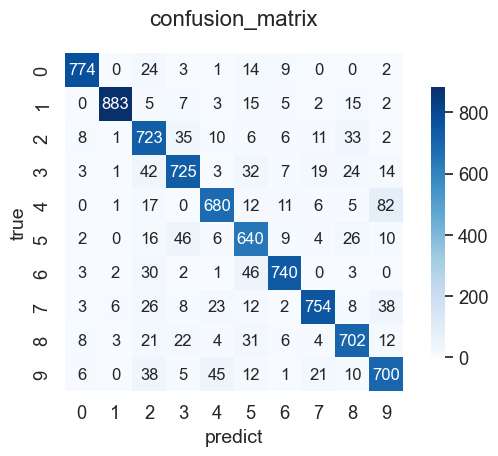


最易混淆的数字对 (错误数 > 10):
  4 → 9: 82 次错误
  5 → 3: 46 次错误
  6 → 5: 46 次错误
  9 → 4: 45 次错误
  3 → 2: 42 次错误
  7 → 9: 38 次错误
  9 → 2: 38 次错误
  2 → 3: 35 次错误
  2 → 8: 33 次错误
  3 → 5: 32 次错误

进行 5 折交叉验证...

创建集成贝叶斯模型...
交叉验证结果:
各折准确率: ['0.8751', '0.8650', '0.8698', '0.8657', '0.8757']
平均准确率: 0.8703 (±0.0045)

训练结果总结:
最终准确率: 0.8715


In [106]:
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.ensemble import VotingClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_selection import VarianceThreshold
import joblib
import time


class DigitRecognizer:
    def __init__(self, n_components=200, random_state=42):
        self.n_components = n_components
        self.random_state = random_state
        self.model = None
        self.pca = None
        self.scaler = None
        self.feature_selector = None
        self.accuracy = 0.0

    def load_data(self, data_path, sample_frac=1.0):
        df = pd.read_csv(data_path)

        if sample_frac < 1.0:
            df = df.sample(frac=sample_frac, random_state=self.random_state)
            print(f"随机抽样 {sample_frac * 100}% 的数据")

        X = df.iloc[:, 1:].values
        y = df.iloc[:, 0].values

        print(f"数据加载完成!")
        print(f"样本数量: {len(X)}")
        print(f"特征维度: {X.shape[1]}")
        print(f"类别分布: {dict(zip(*np.unique(y, return_counts=True)))}")

        return X, y

    def advanced_feature_engineering(self, X, y, test_size=0.2):
        X_normalized = X / 255.0

        self.feature_selector = VarianceThreshold(threshold=0.001)
        X_selected = self.feature_selector.fit_transform(X_normalized)
        print(f"方差特征选择: 784 -> {X_selected.shape[1]} 个特征")

        self.pca = PCA(n_components=self.n_components, random_state=self.random_state)
        X_pca = self.pca.fit_transform(X_selected)

        self.scaler = StandardScaler()
        X_scaled = self.scaler.fit_transform(X_pca)

        print(f"PCA降维: {X_selected.shape[1]} -> {X_pca.shape[1]} 个特征")
        print(f"PCA保留方差比例: {self.pca.explained_variance_ratio_.sum():.4f}")

        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y, test_size=test_size, random_state=self.random_state, stratify=y
        )

        print(f"数据划分完成:")
        print(f"- 训练集: {X_train.shape}")
        print(f"- 测试集: {X_test.shape}")

        return X_train, X_test, y_train, y_test

    def create_ensemble_model(self):
        print("\n" + "=" * 60)
        print("创建集成贝叶斯模型...")

        estimators = [
            ('gaussian_nb', GaussianNB(var_smoothing=1e-9)),
            ('bernoulli_nb', BernoulliNB(alpha=0.1, binarize=0.3)),
            ('gaussian_nb2', GaussianNB(var_smoothing=1e-7)),
        ]

        ensemble_model = VotingClassifier(
            estimators=estimators,
            voting='soft',
            n_jobs=-1
        )

        return ensemble_model

    def train_and_evaluate(self, X_train, X_test, y_train, y_test):
        start_time = time.time()

        self.model = self.create_ensemble_model()
        self.model.fit(X_train, y_train)

        training_time = time.time() - start_time
        print(f"模型训练完成! 耗时: {training_time:.2f}秒")

        print("\n" + "=" * 60)
        print("模型评估结果:")

        train_accuracy = self.model.score(X_train, y_train)
        print(f"训练集准确率: {train_accuracy:.4f}")

        y_pred = self.model.predict(X_test)
        self.accuracy = accuracy_score(y_test, y_pred)

        print(f"测试集准确率: {self.accuracy:.4f}")
        print(f"错误分类数: {np.sum(y_pred != y_test)}/{len(y_test)}")

        self.detailed_evaluation(y_test, y_pred)

        return y_pred

    def detailed_evaluation(self, y_true, y_pred):
        print("\n详细分类报告:")
        print(classification_report(y_true, y_pred))

        cm = confusion_matrix(y_true, y_pred)
        print("混淆矩阵 (行:真实标签, 列:预测标签):")
        print("   " + " ".join(f"{i:2d}" for i in range(10)))
        print("  " + "-" * 30)
        for i in range(10):
            print(f"{i} | " + " ".join(f"{cm[i, j]:2d}" for j in range(10)))

        labels = [f"{i}" for i in range(len(np.unique(y_true)))]


        plt.style.use('default')  
        plt.rcParams['figure.facecolor'] = 'white' 
        plt.rcParams['axes.facecolor'] = 'white'
        sns.set(font_scale=1.2)
        ax = sns.heatmap(cm,
                         annot=True,
                         fmt='d', 
                         cmap='Blues',  
                         cbar_kws={'shrink': 0.8},  
                         square=True,  
                         xticklabels=labels,
                         yticklabels=labels,
                         annot_kws={"size": 12})  
    
        plt.xlabel('predict', fontsize=14)
        plt.ylabel('true', fontsize=14)
        plt.title('confusion_matrix', fontsize=16, pad=20)
        plt.tight_layout()
        plt.show()

        print("\n最易混淆的数字对 (错误数 > 10):")
        confusion_pairs = []
        for i in range(10):
            for j in range(10):
                if i != j and cm[i, j] > 10:
                    confusion_pairs.append((i, j, cm[i, j]))

        confusion_pairs.sort(key=lambda x: x[2], reverse=True)
        for i, j, count in confusion_pairs[:10]:
            print(f"  {i} → {j}: {count} 次错误")

    def cross_validation(self, X, y, cv=5):
        print("\n" + "=" * 60)
        print(f"进行 {cv} 折交叉验证...")

        X_normalized = X / 255.0
        if self.feature_selector is not None:
            X_selected = self.feature_selector.transform(X_normalized)
        else:
            X_selected = X_normalized

        X_pca = self.pca.transform(X_selected)
        X_scaled = self.scaler.transform(X_pca)

        model = self.create_ensemble_model()
        scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='accuracy', n_jobs=-1)

        print(f"交叉验证结果:")
        print(f"各折准确率: {[f'{s:.4f}' for s in scores]}")
        print(f"平均准确率: {scores.mean():.4f} (±{scores.std():.4f})")

        return scores

    def predict_single(self, pixel_list):
        if self.model is None:
            raise ValueError("请先训练模型!")

        pixel_array = np.array(pixel_list, dtype=np.float32).reshape(1, -1)
        pixel_normalized = pixel_array / 255.0

        if self.feature_selector is not None:
            pixel_selected = self.feature_selector.transform(pixel_normalized)
        else:
            pixel_selected = pixel_normalized

        pixel_pca = self.pca.transform(pixel_selected)
        pixel_scaled = self.scaler.transform(pixel_pca)

        prediction = self.model.predict(pixel_scaled)[0]
        probability = self.model.predict_proba(pixel_scaled)[0]

        return prediction, probability

    def predict_batch(self, pixel_lists):
        if self.model is None:
            raise ValueError("请先训练模型!")

        pixel_array = np.array(pixel_lists, dtype=np.float32)
        pixel_normalized = pixel_array / 255.0

        if self.feature_selector is not None:
            pixel_selected = self.feature_selector.transform(pixel_normalized)
        else:
            pixel_selected = pixel_normalized

        pixel_pca = self.pca.transform(pixel_selected)
        pixel_scaled = self.scaler.transform(pixel_pca)

        predictions = self.model.predict(pixel_scaled)
        probabilities = self.model.predict_proba(pixel_scaled)

        return predictions, probabilities

    def load_model(self, filepath='improved_digit_bayes_model.joblib'):
        model_data = joblib.load(filepath)

        self.model = model_data['model']
        self.pca = model_data['pca']
        self.scaler = model_data['scaler']
        self.feature_selector = model_data['feature_selector']
        self.accuracy = model_data['accuracy']
        self.n_components = model_data.get('n_components', 100)

        print(f"模型已加载，准确率: {self.accuracy:.4f}")

        return True


print("=" * 60)
print("改进版手写数字识别 - 贝叶斯分类器")
print("=" * 60)

model = DigitRecognizer(n_components=100, random_state=42)

try:
    data_path = './digit-recognizer/train.csv'  # 修改为您的数据文件路径
    X, y = model.load_data(data_path, sample_frac=1.0)

    X_train, X_test, y_train, y_test = model.advanced_feature_engineering(X, y, test_size=0.2)

    y_pred = model.train_and_evaluate(X_train, X_test, y_train, y_test)

    model.cross_validation(X, y, cv=5)

    print("\n" + "=" * 60)
    print("训练结果总结:")
    print(f"最终准确率: {model.accuracy:.4f}")

except FileNotFoundError:
    print(f"错误：未找到数据文件!")
    print("请确保数据文件存在并修改代码中的文件路径")
except Exception as e:
    print(f"运行错误: {str(e)}")
    import traceback

    traceback.print_exc()

In [101]:
from load_proto import simple_digit_processing_quick

# str = '0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	80	218	254	254	163	14	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	6	188	254	253	253	253	253	122	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	11	213	253	254	236	111	238	253	238	31	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	15	178	253	235	26	19	0	227	253	245	41	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	118	253	230	23	0	0	47	241	253	218	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	30	244	250	105	0	0	59	229	253	253	133	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	105	253	235	1	27	115	248	253	253	248	39	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	87	253	249	194	253	254	253	253	253	107	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	22	196	244	211	156	223	253	253	208	10	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	254	253	253	26	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	116	255	254	108	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	33	250	254	161	7	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	5	164	253	235	6	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	36	253	253	48	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	14	212	253	192	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	5	148	253	245	14	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	75	253	251	128	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	19	207	253	199	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	111	253	243	62	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	19	230	253	166	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0'

# pixels = str.split('	')
# 
# X_test = np.array(pixels)

# X_test = simple_digit_processing_quick('/Users/Liuhaixin/Downloads/9-2.png')

X_test = simple_digit_processing_quick('8.png')

predictions, possible = model.predict_single(X_test)

print(predictions, possible)

8 [0.00473443 0.02158695 0.20351708 0.07634237 0.00049042 0.02198373
 0.30893898 0.00037629 0.33304216 0.0289876 ]
